# Radiomics-Enhanced Self-Supervised Vision Transformer (RE-SSViT)
## Mammographic Lesion Classification on the Uploaded CBIS-DDSM Kaggle Sample

This notebook implements only the **proposed RE-SSViT workflow** from the supplied research document. It does **not** include baseline-model comparisons.

Implemented methodology:

**CBIS-DDSM sample → preprocessing → ROI preparation → radiomic extraction → masked-image self-supervised ViT pretraining → ViT embeddings → radiomic/deep feature normalization → feature fusion → fine-tuning → Benign/Malignant classification → evaluation.**

The final evaluation uses the metrics explicitly reported in the paper: **Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, ROC curve**, plus training/validation accuracy and loss curves.

In [1]:
# Cell 1 — Imports, reproducibility, and runtime configuration
import os, re, sys, math, random, time, warnings, zipfile, glob
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import perimeter

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
sns.set_theme(context='notebook', style='whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
PATCH_SIZE = 32          # paper does not prescribe patch size; chosen for this sample-scale implementation
EMBED_DIM = 64
NUM_HEADS = 4
NUM_LAYERS = 2
MASK_RATIO = 0.40
SSL_EPOCHS = 4
FT_EPOCHS = 18
PATIENCE = 5
BATCH_SIZE = 16

print(f'Python: {sys.version.split()[0]} | PyTorch: {torch.__version__}')
print(f'Device: {DEVICE} | CPU threads: {torch.get_num_threads()}')
print(f'Input size: {IMG_SIZE}x{IMG_SIZE} | Patch size: {PATCH_SIZE} | Tokens/image: {(IMG_SIZE//PATCH_SIZE)**2}')
print(f'SSL epochs: {SSL_EPOCHS} | Fine-tuning max epochs: {FT_EPOCHS} | Seed: {SEED}')

Python: 3.13.5 | PyTorch: 2.10.0+cpu
Device: cpu | CPU threads: 4
Input size: 224x224 | Patch size: 32 | Tokens/image: 49
SSL epochs: 4 | Fine-tuning max epochs: 18 | Seed: 42


In [2]:
# Cell 2 — Locate/extract the uploaded CBIS-DDSM sample
ZIP_CANDIDATES = [
    Path('/mnt/data/CBIS_DDSM.zip'),
    Path('/content/CBIS_DDSM.zip'),
    Path('CBIS_DDSM.zip')
]
ZIP_PATH = next((p for p in ZIP_CANDIDATES if p.exists()), None)

EXTRACT_ROOT = Path('/mnt/data/CBIS_DDSM_extracted') if Path('/mnt/data').exists() else Path('./CBIS_DDSM_extracted')
DATA_ROOT = EXTRACT_ROOT / 'CBIS_DDSM'

if not DATA_ROOT.exists():
    if ZIP_PATH is None:
        raise FileNotFoundError('CBIS_DDSM.zip was not found. Upload it and rerun this cell.')
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_ROOT)

all_files = [p for p in DATA_ROOT.rglob('*') if p.is_file()]
jpg_files = list((DATA_ROOT/'jpeg').rglob('*.jpg'))
csv_files = list((DATA_ROOT/'csv').glob('*.csv'))

print(f'Dataset root: {DATA_ROOT}')
print(f'Total files: {len(all_files)}')
print(f'JPEG images: {len(jpg_files)}')
print(f'CSV files: {len(csv_files)}')
print('CSV names:', [p.name for p in sorted(csv_files)])

Dataset root: /mnt/data/CBIS_DDSM_extracted/CBIS_DDSM
Total files: 797
JPEG images: 792
CSV files: 5
CSV names: ['calc_case_description_test_set.csv', 'calc_case_description_train_set.csv', 'dicom_info.csv', 'mass_case_description_test_set.csv', 'mass_case_description_train_set.csv']


In [3]:
# Cell 3 — Load the four case-description tables and DICOM-to-JPEG metadata
csv_dir = DATA_ROOT / 'csv'

specs = [
    ('mass_case_description_train_set.csv', 'train', 'mass'),
    ('mass_case_description_test_set.csv', 'test', 'mass'),
    ('calc_case_description_train_set.csv', 'train', 'calcification'),
    ('calc_case_description_test_set.csv', 'test', 'calcification'),
]

parts=[]
for filename, split, lesion_group in specs:
    df = pd.read_csv(csv_dir/filename)
    if 'breast_density' in df.columns:
        df['breast density'] = df['breast_density']
    df['_split'] = split
    df['_lesion_group'] = lesion_group
    df['_source_csv'] = filename
    parts.append(df)

cases = pd.concat(parts, ignore_index=True, sort=False)
dicom = pd.read_csv(csv_dir/'dicom_info.csv')

cases['case_index'] = np.arange(len(cases), dtype=int)
cases['target'] = (cases['pathology'].astype(str).str.upper() == 'MALIGNANT').astype(int)
cases['target_name'] = cases['target'].map({0:'Benign', 1:'Malignant'})

print('Combined lesion records:', len(cases))
print('Unique patients:', cases['patient_id'].nunique())
print(); print('Provided split:')
print(cases['_split'].value_counts().to_string())
print(); print('Pathology values:')
print(cases['pathology'].value_counts().to_string())

Combined lesion records: 278
Unique patients: 123

Provided split:
_split
train    236
test      42

Pathology values:
pathology
BENIGN                     131
MALIGNANT                  104
BENIGN_WITHOUT_CALLBACK     43


In [4]:
# Cell 4 — Reconcile CSV DICOM references to the JPEGs physically present in this sample
# The sample stores converted JPEG files. We match by SeriesInstanceUID from the case CSV paths.
uid_re = re.compile(r'(1\.3\.6\.1\.4\.1\.9590\.100\.1\.2\.\d+)')

def extract_series_uid(path_text):
    hits = uid_re.findall(str(path_text))
    return hits[-1] if hits else None

def to_local_jpeg(image_path):
    rel = str(image_path).replace('CBIS-DDSM/', 'CBIS_DDSM/')
    return str(EXTRACT_ROOT / rel)

dicom['local_path'] = dicom['image_path'].map(to_local_jpeg)
dicom_present = dicom[dicom['local_path'].map(os.path.exists)].copy()

for col in ['image file path', 'cropped image file path', 'ROI mask file path']:
    cases[col + '_series_uid'] = cases[col].map(extract_series_uid)

def resolve_series(series_uid, kind):
    cand = dicom_present[dicom_present['SeriesInstanceUID'].astype(str) == str(series_uid)].copy()
    if len(cand) == 0:
        return None
    desc = cand['SeriesDescription'].fillna('').str.lower()
    if kind == 'full':
        hit = cand[desc.str.contains('full mammogram')]
        return (hit.iloc[0] if len(hit) else cand.iloc[0])['local_path']
    if kind == 'crop':
        hit = cand[desc.str.contains('cropped')]
        if len(hit):
            return hit.iloc[0]['local_path']
        # Shared crop/mask series with missing description: crop is the smaller image.
        cand['_area'] = cand['Rows'].fillna(0) * cand['Columns'].fillna(0)
        return cand.sort_values('_area').iloc[0]['local_path']
    if kind == 'mask':
        hit = cand[desc.str.contains('roi mask')]
        if len(hit):
            return hit.iloc[0]['local_path']
        # Shared crop/mask series with missing description: mask is the larger image.
        cand['_area'] = cand['Rows'].fillna(0) * cand['Columns'].fillna(0)
        return cand.sort_values('_area').iloc[-1]['local_path']
    raise ValueError(kind)

cases['full_path'] = cases['image file path_series_uid'].map(lambda x: resolve_series(x, 'full'))
cases['crop_path'] = cases['cropped image file path_series_uid'].map(lambda x: resolve_series(x, 'crop'))
cases['mask_path'] = cases['ROI mask file path_series_uid'].map(lambda x: resolve_series(x, 'mask'))

for col in ['full_path','crop_path','mask_path']:
    cases[col+'_exists'] = cases[col].map(lambda p: bool(p) and os.path.exists(p))

print('Physical JPEG metadata rows:', len(dicom_present))
print('Resolved full mammograms:', int(cases['full_path_exists'].sum()), '/', len(cases))
print('Resolved cropped ROIs:', int(cases['crop_path_exists'].sum()), '/', len(cases))
print('Resolved ROI masks:', int(cases['mask_path_exists'].sum()), '/', len(cases))

Physical JPEG metadata rows: 792
Resolved full mammograms: 278 / 278
Resolved cropped ROIs: 278 / 278
Resolved ROI masks: 278 / 278


In [5]:
# Cell 5 — Integrity summary used by the implementation
assert cases[['full_path_exists','crop_path_exists','mask_path_exists']].all().all(), 'Unresolved image path found.'

summary = pd.DataFrame({
    'Item': [
        'Lesion records','Unique patients','Train lesion records','Test lesion records',
        'Unique full mammograms','Cropped ROI images','ROI masks',
        'Mass lesions','Calcification lesions','Benign lesions','Malignant lesions','CC views','MLO views'
    ],
    'Count': [
        len(cases), cases['patient_id'].nunique(),
        (cases['_split']=='train').sum(), (cases['_split']=='test').sum(),
        cases['full_path'].nunique(), cases['crop_path'].nunique(), cases['mask_path'].nunique(),
        (cases['_lesion_group']=='mass').sum(), (cases['_lesion_group']=='calcification').sum(),
        (cases['target']==0).sum(), (cases['target']==1).sum(),
        (cases['image view']=='CC').sum(), (cases['image view']=='MLO').sum()
    ]
})
display(summary)

train_patients=set(cases.loc[cases['_split']=='train','patient_id'])
test_patients=set(cases.loc[cases['_split']=='test','patient_id'])
print('Train/test patient overlap:', len(train_patients & test_patients))
print('Binary target used: 0 = BENIGN or BENIGN_WITHOUT_CALLBACK; 1 = MALIGNANT')

,Item,Count
0,Lesion records,278
1,Unique patients,123
2,Train lesion records,236
3,Test lesion records,42
4,Unique full mammograms,236
5,Cropped ROI images,278
6,ROI masks,278
7,Mass lesions,140
8,Calcification lesions,138
9,Benign lesions,174


Train/test patient overlap: 0
Binary target used: 0 = BENIGN or BENIGN_WITHOUT_CALLBACK; 1 = MALIGNANT


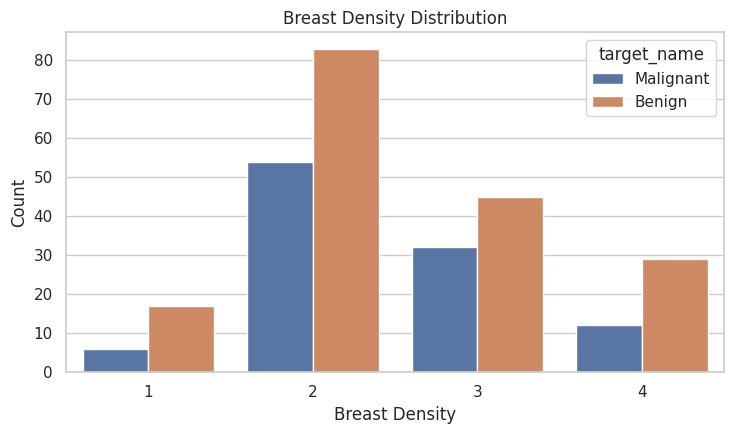

breast density
1     23
2    137
3     77
4     41


In [8]:
# Cell 8 — Breast-density distribution available in the case metadata
plt.figure(figsize=(7.5,4.5))
order = sorted(cases['breast density'].dropna().unique())
ax = sns.countplot(data=cases, x='breast density', order=order, hue='target_name', palette='deep')
ax.set_title('Breast Density Distribution')
ax.set_xlabel('Breast Density'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()
print(cases['breast density'].value_counts(dropna=False).sort_index().to_string())

In [9]:
# Cell 9 — Leakage-safe development split: preserve the provided test set and split TRAIN patients into train/validation
train_pool = cases[cases['_split']=='train'].copy().reset_index(drop=True)
test_df = cases[cases['_split']=='test'].copy().reset_index(drop=True)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf.split(train_pool, y=train_pool['target'], groups=train_pool['patient_id']))
train_df = train_pool.iloc[tr_idx].copy().reset_index(drop=True)
val_df = train_pool.iloc[va_idx].copy().reset_index(drop=True)

split_table = pd.DataFrame({
    'Split':['Train','Validation','Test'],
    'Lesions':[len(train_df),len(val_df),len(test_df)],
    'Patients':[train_df.patient_id.nunique(),val_df.patient_id.nunique(),test_df.patient_id.nunique()],
    'Benign':[(train_df.target==0).sum(),(val_df.target==0).sum(),(test_df.target==0).sum()],
    'Malignant':[(train_df.target==1).sum(),(val_df.target==1).sum(),(test_df.target==1).sum()]
})
display(split_table)
print('Train/validation patient overlap:', len(set(train_df.patient_id) & set(val_df.patient_id)))
print('Development/test patient overlap:', len((set(train_df.patient_id)|set(val_df.patient_id)) & set(test_df.patient_id)))

,Split,Lesions,Patients,Benign,Malignant
0,Train,189,81,115,74
1,Validation,47,18,29,18
2,Test,42,24,30,12


Train/validation patient overlap: 0
Development/test patient overlap: 0


In [11]:
# Cell 11 — Preprocess SSL full mammograms, batch 1/4
start=time.time(); batch=ssl_full_paths[0:50]
for p in batch: full_cache[p]=preprocess_image(p)
print(f'Cached SSL full mammograms: {len(full_cache)}/{len(ssl_full_paths)} | batch time {time.time()-start:.1f} s')

Cached SSL full mammograms: 50/196 | batch time 13.2 s


In [13]:
# Cell 13 — Preprocess SSL full mammograms, batch 3/4
start=time.time(); batch=ssl_full_paths[100:150]
for p in batch: full_cache[p]=preprocess_image(p)
print(f'Cached SSL full mammograms: {len(full_cache)}/{len(ssl_full_paths)} | batch time {time.time()-start:.1f} s')

Cached SSL full mammograms: 150/196 | batch time 10.8 s


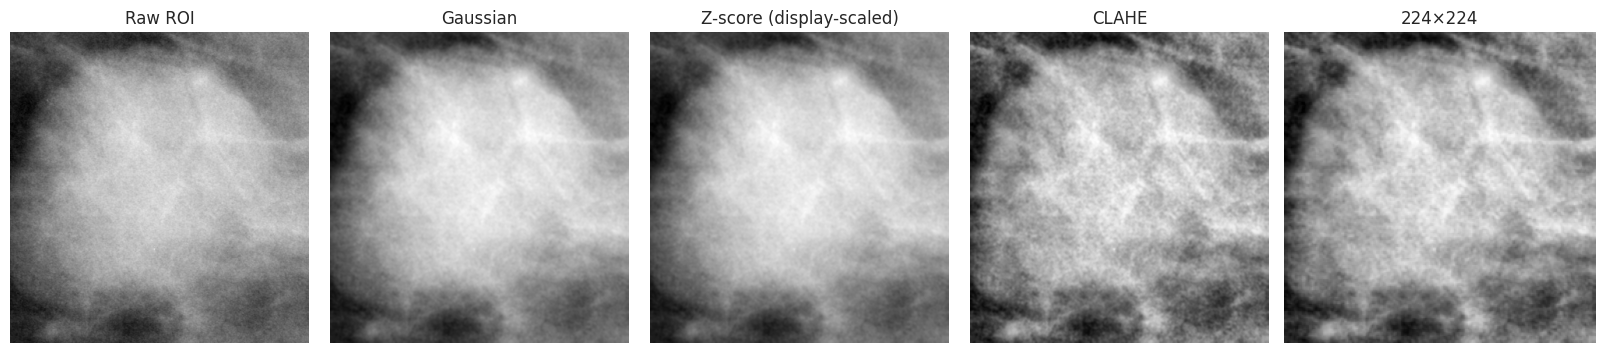

Displayed sample: 2-004.jpg


In [15]:
# Cell 15 — Visual check of the paper-defined preprocessing stages on one actual training ROI
sample_path = train_df.iloc[0]['crop_path']
raw, den, norm8, clahe_img, resized = preprocess_image(sample_path, return_stages=True)

fig, axes = plt.subplots(1,5, figsize=(16,3.4), constrained_layout=True)
for ax, img, title in zip(
    axes, [raw,den,norm8,clahe_img,resized],
    ['Raw ROI','Gaussian','Z-score (display-scaled)','CLAHE','224×224']
):
    ax.imshow(img, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.show()
print('Displayed sample:', Path(sample_path).name)

In [16]:
# Cell 16 — Radiomic feature extraction: first-order, GLCM texture, and ROI-mask shape descriptors
# Compactness follows the paper equation: P^2 / (4*pi*A). Circularity is its reciprocal form 4*pi*A/P^2.

def extract_radiomics(roi_img, mask_path):
    x = roi_img.astype(np.float32)
    flat = x.ravel()

    # First-order intensity features
    mean_v = float(flat.mean())
    var_v = float(flat.var())
    skew_v = float(skew(flat, bias=False))
    kurt_v = float(kurtosis(flat, fisher=True, bias=False))

    # GLCM texture features using a fixed 32-level quantization for consistent computation.
    q = np.floor(x / 256.0 * 32).clip(0,31).astype(np.uint8)
    glcm = graycomatrix(q, distances=[1], angles=[0,np.pi/4,np.pi/2,3*np.pi/4],
                        levels=32, symmetric=True, normed=True)
    contrast = float(graycoprops(glcm,'contrast').mean())
    homogeneity = float(graycoprops(glcm,'homogeneity').mean())
    energy = float(graycoprops(glcm,'energy').mean())
    correlation = float(graycoprops(glcm,'correlation').mean())
    p = glcm.astype(np.float64)
    entropy = float((-(p*np.log2(p+1e-12))).sum(axis=(0,1)).mean())

    # Shape from the supplied ROI mask, normalized to the common 224x224 canvas.
    mask = load_gray(mask_path)
    mask = cv2.resize(mask, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    binary = mask > 0
    area = float(binary.sum())
    perim = float(perimeter(binary, neighborhood=8)) if area > 0 else 0.0
    compactness = float((perim**2)/(4*math.pi*area+1e-12)) if area > 0 else 0.0
    circularity = float((4*math.pi*area)/(perim**2+1e-12)) if perim > 0 else 0.0
    area_fraction = float(area/(IMG_SIZE*IMG_SIZE))

    return {
        'mean_intensity':mean_v, 'variance':var_v, 'skewness':skew_v, 'kurtosis':kurt_v,
        'glcm_contrast':contrast, 'glcm_homogeneity':homogeneity,
        'glcm_energy':energy, 'glcm_correlation':correlation, 'glcm_entropy':entropy,
        'area':area, 'perimeter':perim, 'compactness':compactness,
        'circularity':circularity, 'area_fraction':area_fraction
    }

example = extract_radiomics(roi_cache[train_df.iloc[0]['crop_path']], train_df.iloc[0]['mask_path'])
print('Radiomic features implemented:', list(example.keys()))
print('Number of radiomic features:', len(example))

Radiomic features implemented: ['mean_intensity', 'variance', 'skewness', 'kurtosis', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 'glcm_entropy', 'area', 'perimeter', 'compactness', 'circularity', 'area_fraction']
Number of radiomic features: 14


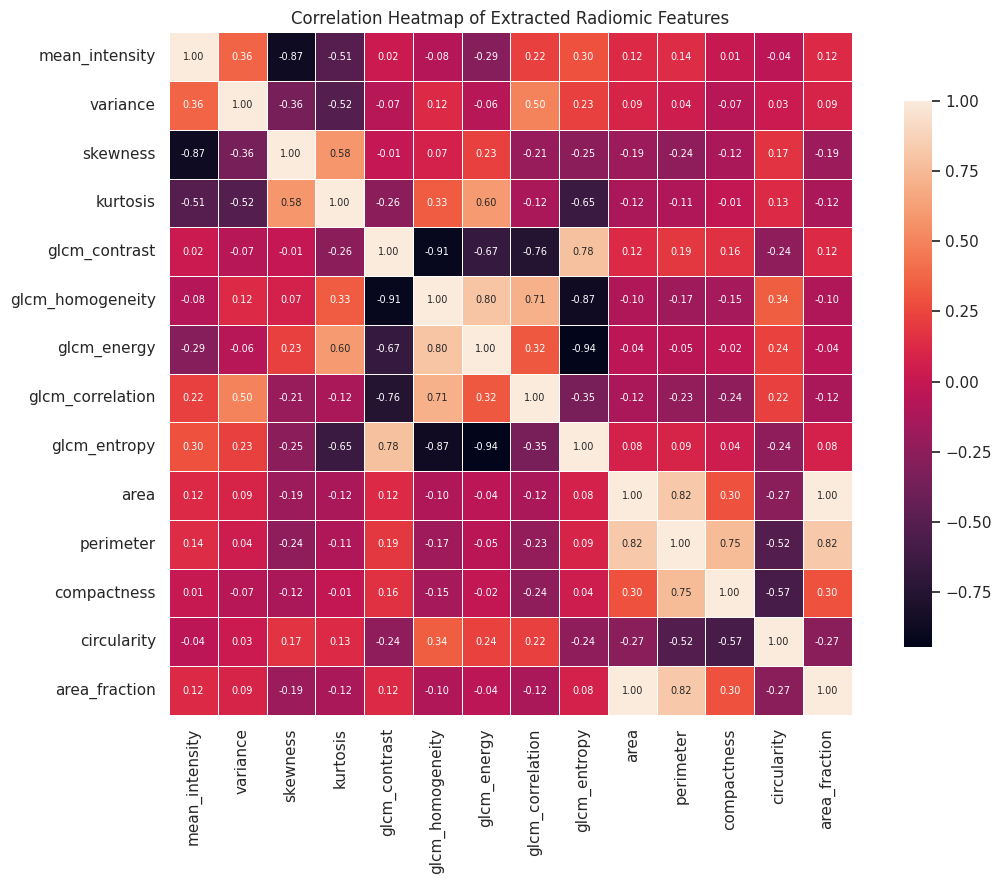

Correlation matrix shape: (14, 14)


In [21]:
# Cell 21 — Radiomic correlation heatmap (paper-aligned analysis)
plt.figure(figsize=(12,9))
corr = radiomics_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', linewidths=.4, square=True,
            cbar_kws={'shrink':0.8}, annot_kws={'size':7})
plt.title('Correlation Heatmap of Extracted Radiomic Features')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()
print('Correlation matrix shape:', corr.shape)

In [22]:
# Cell 22 — Dataset objects for masked-image self-supervision and supervised lesion classification
class SSLDataset(Dataset):
    def __init__(self, paths, cache):
        self.paths=list(paths); self.cache=cache
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        x = self.cache[self.paths[idx]].astype(np.float32)/255.0
        return torch.from_numpy(x).unsqueeze(0)

class LesionDataset(Dataset):
    def __init__(self, frame, cache, rad_matrix, augment=False):
        self.frame=frame.copy().reset_index(drop=True)
        self.cache=cache; self.rad=rad_matrix; self.augment=augment
    def __len__(self): return len(self.frame)
    def __getitem__(self, idx):
        row=self.frame.iloc[idx]
        x=self.cache[row['crop_path']].copy()
        if self.augment:
            if np.random.rand()<0.5: x=np.fliplr(x).copy()
            angle=float(np.random.uniform(-8,8))
            scale=float(np.random.uniform(0.95,1.05))
            M=cv2.getRotationMatrix2D((IMG_SIZE/2,IMG_SIZE/2),angle,scale)
            x=cv2.warpAffine(x,M,(IMG_SIZE,IMG_SIZE),flags=cv2.INTER_LINEAR,borderMode=cv2.BORDER_REFLECT_101)
        x=torch.from_numpy(x.astype(np.float32)/255.0).unsqueeze(0)
        r=torch.tensor(self.rad[int(row['case_index'])],dtype=torch.float32)
        y=torch.tensor(float(row['target']),dtype=torch.float32)
        return x,r,y

ssl_loader = DataLoader(SSLDataset(ssl_full_paths, full_cache), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print('SSL images:', len(ssl_loader.dataset), '| SSL batches:', len(ssl_loader))

SSL images: 196 | SSL batches: 13


In [23]:
# Cell 16 — Compact Vision Transformer with Masked Image Modeling (MIM)
class MIMViT(nn.Module):
    def __init__(self, img_size=224, patch_size=32, embed_dim=64, heads=4, layers=2):
        super().__init__()
        self.img_size=img_size; self.patch_size=patch_size
        self.num_patches=(img_size//patch_size)**2
        self.patch_embed=nn.Conv2d(1,embed_dim,kernel_size=patch_size,stride=patch_size)
        self.pos_embed=nn.Parameter(torch.zeros(1,self.num_patches,embed_dim))
        self.mask_token=nn.Parameter(torch.zeros(1,1,embed_dim))
        enc_layer=nn.TransformerEncoderLayer(
            d_model=embed_dim,nhead=heads,dim_feedforward=embed_dim*2,
            dropout=0.1,activation='gelu',batch_first=True,norm_first=True
        )
        self.encoder=nn.TransformerEncoder(enc_layer,num_layers=layers)
        self.norm=nn.LayerNorm(embed_dim)
        self.decoder=nn.Linear(embed_dim,patch_size*patch_size)
        nn.init.trunc_normal_(self.pos_embed,std=0.02)
        nn.init.trunc_normal_(self.mask_token,std=0.02)

    def patch_targets(self,x):
        p=self.patch_size
        patches=x.unfold(2,p,p).unfold(3,p,p)  # B,C,Hn,Wn,p,p
        patches=patches.contiguous().view(x.size(0),1,-1,p,p).squeeze(1)
        return patches.flatten(2)

    def encode(self,x):
        tok=self.patch_embed(x).flatten(2).transpose(1,2)
        z=self.encoder(tok+self.pos_embed)
        z=self.norm(z)
        return z.mean(dim=1)

    def mim_loss(self,x,mask_ratio=0.4):
        tok=self.patch_embed(x).flatten(2).transpose(1,2)
        B,N,D=tok.shape
        mask=(torch.rand(B,N,device=x.device)<mask_ratio)
        # guarantee at least one masked patch per image
        mask[:,0]=True
        masked_tok=torch.where(mask.unsqueeze(-1),self.mask_token.expand(B,N,D),tok)
        z=self.encoder(masked_tok+self.pos_embed)
        z=self.norm(z)
        pred=self.decoder(z)
        target=self.patch_targets(x)
        per_patch=((pred-target)**2).mean(dim=-1)
        return per_patch[mask].mean()

vit = MIMViT(IMG_SIZE,PATCH_SIZE,EMBED_DIM,NUM_HEADS,NUM_LAYERS).to(DEVICE)
params=sum(p.numel() for p in vit.parameters())
print(vit)
print(f'Trainable ViT parameters: {params:,}')

MIMViT(
  (patch_embed): Conv2d(1, 64, kernel_size=(32, 32), stride=(32, 32))
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (decoder): Linear(in_features=64, out_features=1024, bias=True)
)
Trainable ViT parameters: 202,432


In [ ]:
# Cell 17 — Self-supervised MIM pretraining on TRAIN full mammograms only
ssl_opt=torch.optim.Adam(vit.parameters(),lr=1e-3,weight_decay=1e-4)
ssl_history=[]
best_ssl=float('inf'); best_ssl_state=None

for epoch in range(1,SSL_EPOCHS+1):
    vit.train(); losses=[]
    for x in ssl_loader:
        x=x.to(DEVICE)
        ssl_opt.zero_grad(set_to_none=True)
        loss=vit.mim_loss(x,MASK_RATIO)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vit.parameters(),1.0)
        ssl_opt.step()
        losses.append(loss.item())
    mean_loss=float(np.mean(losses)); ssl_history.append(mean_loss)
    if mean_loss < best_ssl:
        best_ssl=mean_loss
        best_ssl_state={k:v.detach().cpu().clone() for k,v in vit.state_dict().items()}
    print(f'SSL epoch {epoch:02d}/{SSL_EPOCHS} | masked-patch MSE: {mean_loss:.6f}')

vit.load_state_dict(best_ssl_state)
print(f'Best SSL reconstruction loss: {best_ssl:.6f}')

In [27]:
# Cell 20 — Radiomics + SSL-ViT fusion model and paper-defined binary classification head
class RESSViTClassifier(nn.Module):
    def __init__(self, pretrained_vit, n_radiomics):
        super().__init__()
        self.vit=pretrained_vit
        # Fine-tune selected transformer layers while preserving most SSL representation.
        for p in self.vit.parameters(): p.requires_grad=False
        for p in self.vit.encoder.layers[-1].parameters(): p.requires_grad=True
        for p in self.vit.norm.parameters(): p.requires_grad=True
        self.projection=nn.Sequential(
            nn.Linear(EMBED_DIM+n_radiomics,64),
            nn.ReLU(),
            nn.Dropout(0.30)
        )
        self.classifier=nn.Linear(64,1)
    def forward(self,x,rad):
        deep=self.vit.encode(x)
        fused=torch.cat([deep,rad],dim=1)  # concatenation fusion from the paper
        z=self.projection(fused)
        return self.classifier(z).squeeze(1)

model=RESSViTClassifier(vit,len(RAD_COLS)).to(DEVICE)
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
total=sum(p.numel() for p in model.parameters())
print(model)
print(f'Trainable parameters during fine-tuning: {trainable:,} / {total:,}')
print('Fusion: normalized radiomics + SSL-ViT embedding -> concatenation -> nonlinear projection -> sigmoid probability')

RESSViTClassifier(
  (vit): MIMViT(
    (patch_embed): Conv2d(1, 64, kernel_size=(32, 32), stride=(32, 32))
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (decoder): Linear(in_features=64, out_features=1024, bias=True)
  )
  (projection): Sequenti

In [ ]:
# Cell 21 — Fine-tune with Binary Cross-Entropy, Adam, weighted loss, and early stopping
n_neg=int((train_df.target==0).sum()); n_pos=int((train_df.target==1).sum())
pos_weight=torch.tensor([n_neg/max(n_pos,1)],device=DEVICE,dtype=torch.float32)
criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],lr=3e-4,weight_decay=1e-4)

history={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
best_val=float('inf'); best_state=None; wait=0

def run_epoch(loader,training=False):
    model.train(training)
    losses=[]; ys=[]; probs=[]
    for x,rad,y in loader:
        x,rad,y=x.to(DEVICE),rad.to(DEVICE),y.to(DEVICE)
        if training: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits=model(x,rad)
            loss=criterion(logits,y)
            if training:
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        losses.append(loss.item()); ys.extend(y.detach().cpu().numpy()); probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
    pred=(np.array(probs)>=0.5).astype(int)
    return float(np.mean(losses)), accuracy_score(ys,pred)

for epoch in range(1,FT_EPOCHS+1):
    tr_loss,tr_acc=run_epoch(train_loader,True)
    va_loss,va_acc=run_epoch(val_loader,False)
    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc); history['val_acc'].append(va_acc)
    print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}')
    if va_loss < best_val-1e-4:
        best_val=va_loss; wait=0
        best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        wait += 1
        if wait>=PATIENCE:
            print(f'Early stopping at epoch {epoch}; best validation loss = {best_val:.4f}')
            break

model.load_state_dict(best_state)
print('Best validation checkpoint restored.')

In [ ]:
# Cell 23 — Final untouched TEST evaluation using the metrics mentioned in the paper
model.eval(); y_true=[]; y_prob=[]
with torch.no_grad():
    for x,rad,y in test_loader:
        logits=model(x.to(DEVICE),rad.to(DEVICE))
        y_prob.extend(torch.sigmoid(logits).cpu().numpy())
        y_true.extend(y.numpy())

y_true=np.asarray(y_true,dtype=int); y_prob=np.asarray(y_prob,dtype=float)
y_pred=(y_prob>=0.5).astype(int)

metrics={
    'Accuracy':accuracy_score(y_true,y_pred),
    'Precision':precision_score(y_true,y_pred,zero_division=0),
    'Recall':recall_score(y_true,y_pred,zero_division=0),
    'F1-Score':f1_score(y_true,y_pred,zero_division=0),
    'ROC-AUC':roc_auc_score(y_true,y_prob),
}
metrics_df=pd.DataFrame({'Metric':metrics.keys(),'Value':metrics.values()})
metrics_df['Percent']=metrics_df['Value']*100
print('Final RE-SSViT test metrics (no baseline comparison):')
display(metrics_df.round({'Value':4,'Percent':2}))
print(); print('Classification report:')
print(classification_report(y_true,y_pred,target_names=['Benign','Malignant'],digits=4,zero_division=0))